# Autoemcoder (amomaly detector)

In [1]:
import os
os.chdir('..')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, LeakyReLU, BatchNormalization, Lambda, Concatenate
from tensorflow.keras.models import Model,load_model
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
from tensorflow.keras.losses import binary_crossentropy 

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold

from scripts.load_data import load_data

## Load data

In [3]:
n_test,train_smile,train_nonSmile,test_smile,test_nonSmile=load_data()

n=600

n_train=n-n_test
val_split=0.2
n_val=int(n_train*val_split)

val_smile=train_smile[0:n_val,:,:,:]
val_nonSmile=train_nonSmile[0:n_val]

# Train set 64%
train_smile=train_smile[n_val:,:,:,:]
train_nonSmile=train_nonSmile[n_val:,:,:,:]

val_features=np.concatenate((val_smile, val_nonSmile), axis=0)
val_labels=np.concatenate((np.full(n_val, "smile"), np.full(n_val, "non-smile")))

# Validation set 16%
idxs = np.random.choice(n_val*2, size=n_val*2, replace=False)
val_features = val_features[idxs,:,:,:]
val_labels = val_labels[idxs]

# Test set 20%
test_features=np.concatenate((test_smile, test_nonSmile), axis=0)
test_labels=np.concatenate((np.full(n_test, "smile"), np.full(n_test, "non-smile")))

idxs = np.random.choice(n_test*2, size=n_test*2, replace=False)
test_features = test_features[idxs,:,:,:]
test_labels = test_labels[idxs]

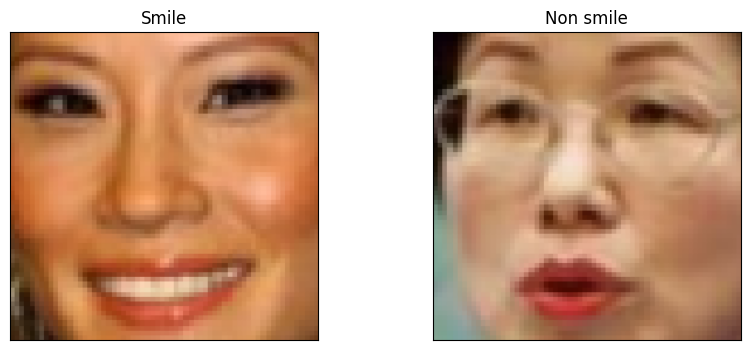

In [4]:
selected = 10
plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
plt.imshow(train_smile[selected,])
ax.set_title('Smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ax = plt.subplot(1, 2, 2)
plt.imshow(train_nonSmile[selected,])
ax.set_title('Non smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

In [5]:
le = LabelEncoder()
test_labels_int = le.fit_transform(test_labels) #smile=1, non-smile=0

## Autoencoder architecture

In [6]:
def combined_loss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)

    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted=brightness**2
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * weighted)

    l1 = tf.reduce_mean(weighted_error)
    return 0.0*bce + 1.0*l1

def add_sobel_channels(x):
    edges = tf.image.sobel_edges(x)   # (B, 200, 200, 2, 3)
    shape = tf.shape(edges)
    # flatten last two dims: 2*3 = 6 channels
    edges = tf.reshape(edges, (shape[0], shape[1], shape[2], 6))
    return edges

In [7]:

input_img = Input(shape=(200, 200, 3))

edges = Lambda(add_sobel_channels)(input_img)
x = Concatenate(axis=-1)([input_img, edges])

x = Conv2D(9, (7,7), activation='leaky_relu', strides=2, padding='same')(x)
x = Conv2D(16, (5,5), activation='leaky_relu', strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation='leaky_relu', strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='leaky_relu', strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='leaky_relu', strides=2, padding='same')(x)
x = BatchNormalization()(x)

encoded = Conv2D(256, 3, strides=2, padding='same')(x)
encoded = LeakyReLU(name="encoded")(encoded)

x = Conv2D(256, (3, 3), activation='leaky_relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='leaky_relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='leaky_relu')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='leaky_relu')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='leaky_relu')(x) 
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation='leaky_relu', padding='same')(x) 
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer=optimizers.Adam(),#1e-3
                    loss=combined_loss,
                    metrics=["mae", "mse"])

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 200, 200,  │          0 │ input_layer[0][0] │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200, 200,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 9)                │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 100, 100,  │      3,978 │ concatenate[0][0] │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 50, 50,    │      3,616 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 50,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 25, 25,    │      4,640 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 13, 13,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoded (LeakyReLU) │ (None, 4, 4, 256) │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 4, 4, 256) │    590,080 │ encoded[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 256) │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │    295,040 │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,337,981 (5.10 MB)

 Trainable params: 1,337,501 (5.10 MB)

 Non-trainable params: 480 (1.88 KB)

## Training

In [8]:
history = autoencoder.fit(train_nonSmile, train_nonSmile,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_split=0.15)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 661ms/step - loss: 0.2320 - mae: 0.1507 - mse: 0.0358 - val_loss: 0.2387 - val_mae: 0.1590 - val_mse: 0.0380
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - loss: 0.1854 - mae: 0.1240 - mse: 0.0257 - val_loss: 0.2286 - val_mae: 0.1535 - val_mse: 0.0357
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step - loss: 0.1512 - mae: 0.1014 - mse: 0.0180 - val_loss: 0.2159 - val_mae: 0.1535 - val_mse: 0.0370
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step - loss: 0.1341 - mae: 0.0892 - mse: 0.0141 - val_loss: 0.2277 - val_mae: 0.1642 - val_mse: 0.0418
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - loss: 0.1375 - mae: 0.0908 - mse: 0.0143 - val_loss: 0.2051 - val_mae: 0.1474 - val_mse: 0.0347
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - loss: 0.1281 - mae: 0.0853 - mse: 0.0128 - val_loss: 0.1945 - val_mae: 0.1359 - val_mse: 0.0294
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step - loss: 0.1187 - mae: 0.0795 - mse: 0.0114 - va

## Save Model

In [9]:
autoencoder.save("model/autoencoder7.keras")

## Load Model

In [ ]:
autoencoder=load_model("model/autoencoder4.keras",custom_objects={"combined_loss": combined_loss,"add_sobel_channels": add_sobel_channels})

## Visualizing compression 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step


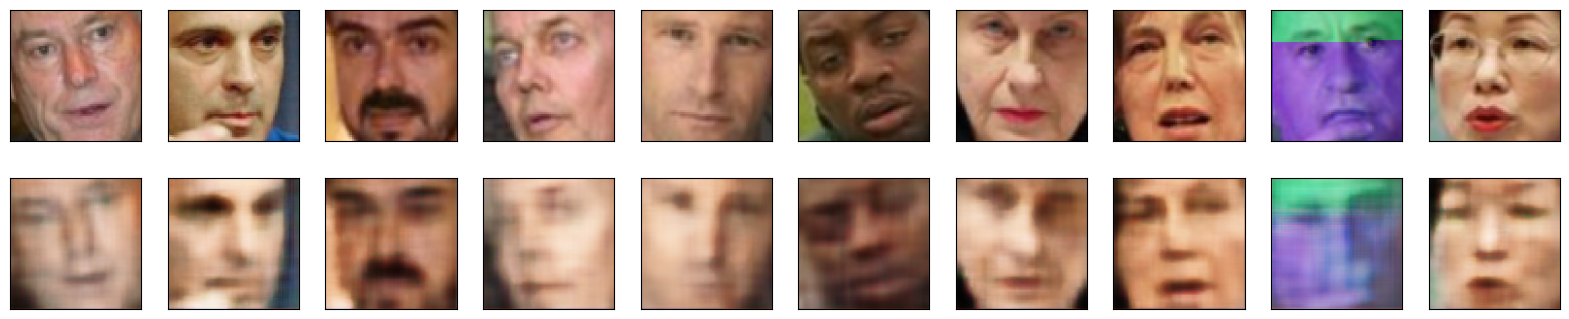

In [10]:
m = 10

decoded_imgs = autoencoder.predict(train_nonSmile[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(train_nonSmile[i+1].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


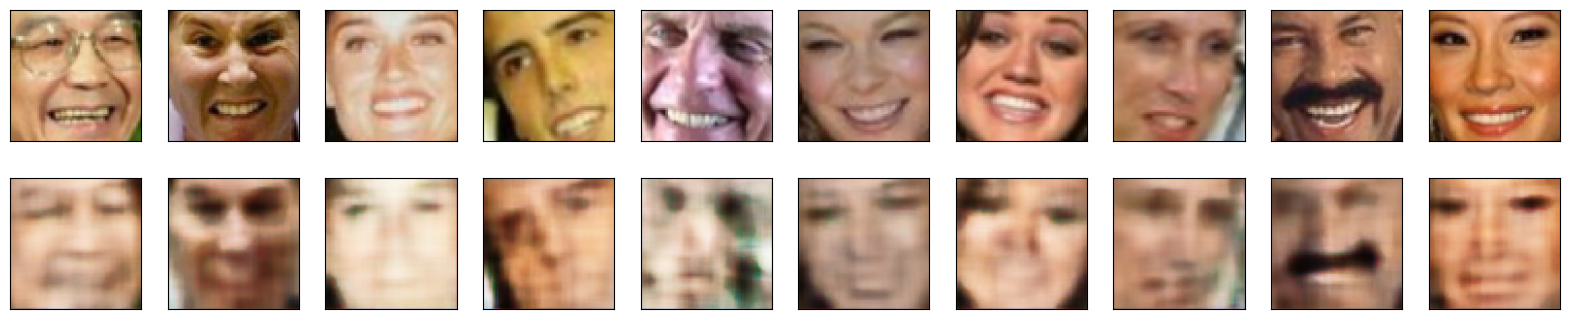

In [11]:
m = 10

decoded_imgs = autoencoder.predict(train_smile[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(train_smile[i+1].reshape(train_smile.shape[1], train_smile.shape[2], train_smile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(train_smile.shape[1], train_smile.shape[2], train_smile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Loss through epochs 

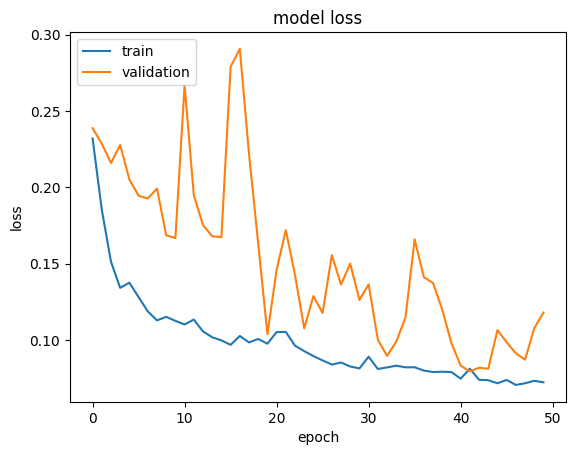

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Epoch range check

In [13]:
# Evaluate the model on the train set and print the loss.
autoencoder.evaluate(train_nonSmile, train_nonSmile) # [loss]

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - loss: 0.1085 - mae: 0.0702 - mse: 0.0080


[0.10853428393602371, 0.07017245143651962, 0.008007471449673176]

In [14]:
autoencoder.evaluate(train_smile, train_smile)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 0.1276 - mae: 0.0832 - mse: 0.0112


[0.12762640416622162, 0.08322836458683014, 0.011194913648068905]

In [25]:
def combined_loss(y_true, y_pred):
    # BCE + L1 
    bce = tf.reduce_mean(binary_crossentropy(y_true, y_pred), axis=[1,2])

    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * brightness)
    
    l1 = tf.reduce_mean(weighted_error, axis=[1,2,3])
    return (0.0*bce + 1.0*l1).numpy()

In [26]:
# Make predictions on the train set.
predictions = autoencoder.predict(train_nonSmile)
train_nonSmile_errors = combined_loss(train_nonSmile,predictions)
threshold = train_nonSmile_errors.mean() + 1 * train_nonSmile_errors.std()
print(threshold)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step
0.15047294


In [27]:
print(np.mean(train_nonSmile_errors))

quantiles = np.quantile(train_nonSmile_errors, [0.0, 0.25, 0.50, 0.75, .90, 1.0])
print(quantiles)

0.12694241
[0.07694798 0.11094638 0.12442296 0.13930121 0.15565522 0.27023864]


## Threshold fine tunning

In [28]:
start=0.10
end = 0.15
step = 0.001
thresholds = np.arange(start, end, step)

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

mean_acc_per_threshold = []

for threshold in thresholds:
    fold_accuracies = []

    # Run K-Fold
    for train_idx, val_idx in skf.split(val_features, val_labels):
        X_train, X_val = val_features[train_idx], val_features[val_idx]
        y_train, y_val = val_labels[train_idx], val_labels[val_idx]

        val_pred = autoencoder.predict(X_val)
        val_errors = combined_loss(X_val, val_pred)

        val_pred_labels = np.where(val_errors > threshold, "smile", "non-smile")

        fold_acc = accuracy_score(y_val, val_pred_labels)
        fold_accuracies.append(fold_acc)

    mean_acc = np.mean(fold_accuracies)
    mean_acc_per_threshold.append(mean_acc)

    print(f"Threshold={threshold:.3f} | Mean CV Acc={mean_acc:.4f}")

# Convert to array
mean_acc_per_threshold = np.array(mean_acc_per_threshold)

# Best threshold
best_index = np.argmax(mean_acc_per_threshold)
best_threshold = thresholds[best_index]

print(f"Best threshold: {best_threshold:.5f}")
print(f"Best mean CV accuracy: {mean_acc_per_threshold[best_index]:.5f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 
Threshold=0.100 | Mean CV Acc=0.5053
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Threshold=0.101 | Mean CV Acc=0.5053
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step 
Threshold=0.102 | Mean CV Acc=0.5001
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step 
Threshold=0.103 | Mean CV Acc=0.5054
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 


## Testing

In [29]:
threshold = best_threshold
test_predictions = autoencoder.predict(test_features)
test_errors = combined_loss(test_features,test_predictions)
test_labels_predictions = np.where(np.array(test_errors) > threshold, 1, 0)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


In [30]:
predictions_str = le.inverse_transform(test_labels_predictions)
pd.crosstab(test_labels, predictions_str, rownames=['True labels'], colnames=['Predicted labels'])

Predicted labels,non-smile,smile
True labels,,
non-smile,52,68
smile,31,89


In [31]:
report=classification_report(test_labels, predictions_str)
print(report)

              precision    recall  f1-score   support

   non-smile       0.63      0.43      0.51       120
       smile       0.57      0.74      0.64       120

    accuracy                           0.59       240
   macro avg       0.60      0.59      0.58       240
weighted avg       0.60      0.59      0.58       240

